# Лекція 2 · демо: як розбиття даних робить метрику

Три експерименти, які показують те саме одним числом:

| # | Що показуємо | Очікуваний ефект |
|---|---|---|
| 1 | випадкове розбиття кадрів проти розбиття за місіями | ROC-AUC падає приблизно з **0.93** до **0.59** |
| 2 | відбір ознак **до** розбиття на чистому шумі | ROC-AUC **0.5 → ~0.8** там, де сигналу немає взагалі |
| 3 | `StandardScaler + PCA` до розбиття проти тих самих кроків усередині `Pipeline` | завищення оцінки на тих самих даних |

Плюс дві перевірки, які я вимагатиму в ЛР: **label-shuffle тест** і **довірчий інтервал** для метрики.

Ноутбук самодостатній: дані генеруються тут, нічого завантажувати не треба.
Потрібні `numpy`, `scikit-learn`, `matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

RS = 0
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})
TRAIN, TEST, ALARM, OK = '#2F6289', '#5B3B70', '#A83620', '#2C6349'

## Дані: 40 польотів, 300 кадрів у кожному

Генератор навмисно відтворює структуру реальних польотних даних:

* **підпис місії** — 8 ознак, спільних для всіх кадрів одного вильоту (борт, тепловізор, освітлення, ділянка місцевості). Усередині місії вони майже не змінюються;
* **частка цілей у місії** різна: одні вильоти майже повністю над ціллю, інші — майже чистий фон;
* **справжній сигнал** — 4 ознаки, слабко пов'язані з наявністю цілі **в конкретному кадрі**.

Саме через другий пункт підпис місії стає предиктивним: дізнавшись, *який це політ*,
модель уже добре вгадує мітку, жодного разу не подивившись на ціль.
Це і є груповий витік — і в реальних датасетах він виникає сам собою, без жодного злого наміру.

In [2]:
# Повертає X (кадри на ознаки), y (чи є ціль у кадрі), groups (id місії), P (частка цілей у місії).
# Ознаки 0..7 — підпис місії (нуйсенс), ознаки 8..11 — слабкий справжній сигнал.
def make_flights(n_missions=40, frames=300, signal=0.35, spread=0.28, noise=0.15, seed=7):
    rng = np.random.default_rng(seed)
    Z = rng.normal(size=(n_missions, 8))                       # підпис кожної місії
    P = rng.beta(spread, spread, n_missions) * 0.94 + 0.03     # частка цілей у місії
    X, y, g = [], [], []
    for m in range(n_missions):
        yi = (rng.random(frames) < P[m]).astype(int)
        nuisance = Z[m] + rng.normal(scale=noise, size=(frames, 8))
        true_sig = signal * yi[:, None] + rng.normal(scale=1.0, size=(frames, 4))
        X.append(np.hstack([nuisance, true_sig])); y.append(yi); g.append(np.full(frames, m))
    return np.vstack(X), np.concatenate(y), np.concatenate(g), P

X, y, groups, P = make_flights()
print('кадрів:', X.shape[0], '| ознак:', X.shape[1], '| місій:', len(np.unique(groups)))
print('частка кадрів із ціллю:  %.2f' % y.mean())
print('частка цілей по місіях:  min %.2f  медіана %.2f  max %.2f' % (P.min(), np.median(P), P.max()))

кадрів: 12000 | ознак: 12 | місій: 40
частка кадрів із ціллю:  0.44
частка цілей по місіях:  min 0.03  медіана 0.30  max 0.97


## Експеримент 1. Той самий код, два розбиття

Модель, гіперпараметри й дані — однакові. Змінюється **тільки те, як проведена межа**
між навчанням і перевіркою.

In [3]:
def forest():
    return RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RS)

# А. Випадкове розбиття кадрів 80/20 — кадри однієї місії по обидва боки межі
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=RS)
auc_random = roc_auc_score(yte, forest().fit(Xtr, ytr).predict_proba(Xte)[:, 1])

# Б. Розбиття за місіями — жодна місія не перетинає межу
gkf = GroupKFold(n_splits=5)
fold_auc = cross_val_score(forest(), X, y, groups=groups, cv=gkf, scoring='roc_auc')

print('випадкове розбиття кадрів   ROC-AUC = %.3f' % auc_random)
print('GroupKFold за mission_id    ROC-AUC = %.3f ± %.3f' % (fold_auc.mean(), fold_auc.std()))
print('по фолдах:', np.round(fold_auc, 3))
print('\nрізниця: %.3f — це не інша модель, це інша процедура вимірювання' % (auc_random - fold_auc.mean()))

випадкове розбиття кадрів   ROC-AUC = 0.929
GroupKFold за mission_id    ROC-AUC = 0.594 ± 0.048
по фолдах: [0.591 0.631 0.598 0.645 0.507]

різниця: 0.335 — це не інша модель, це інша процедура вимірювання


### Чому так вийшло

Подивимось, куди модель насправді дивилась: ознаки 0–7 — це підпис місії,
ознаки 8–11 — єдине, що взагалі пов'язане з ціллю в конкретному кадрі.

внесок підпису місії (ознаки 0–7):    84.1 %
внесок справжнього сигналу (8–11):    15.9 %


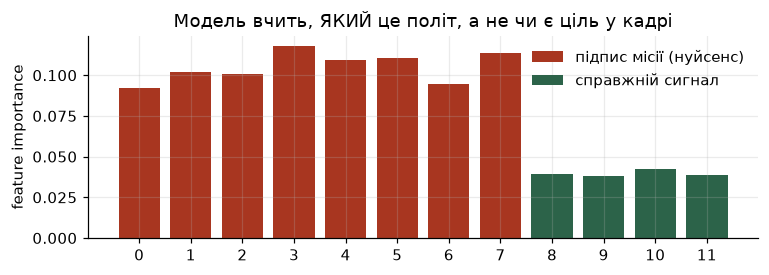

In [4]:
imp = forest().fit(Xtr, ytr).feature_importances_
print('внесок підпису місії (ознаки 0–7):    %.1f %%' % (100*imp[:8].sum()))
print('внесок справжнього сигналу (8–11):    %.1f %%' % (100*imp[8:].sum()))

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.bar(range(8), imp[:8], color=ALARM, label='підпис місії (нуйсенс)')
ax.bar(range(8, 12), imp[8:], color=OK, label='справжній сигнал')
ax.set_xticks(range(12)); ax.set_ylabel('feature importance')
ax.set_title('Модель вчить, ЯКИЙ це політ, а не чи є ціль у кадрі')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

**Червоний прапорець №2 зі слайдів:** одна група ознак забирає майже весь внесок.
У реальних даних це виглядає так само — «дивна» ознака з величезним importance
майже завжди виявляється ідентифікатором, датою або постфактум-полем.

## Експеримент 2. Препроцесинг до розбиття — на даних, де сигналу немає взагалі

Найчистіша демонстрація витоку через препроцесинг: 200 прикладів, 2 000 ознак
**чистого шуму** і **випадкові мітки**. Чесна відповідь тут може бути тільки одна — 0.5.

Відбираємо 100 «найкорельованіших» ознак **до** крос-валідації — і отримуємо
класифікатор, який упевнено «працює» на даних, у яких за побудовою немає чого знаходити.

In [5]:
rng = np.random.default_rng(1)
Xn = rng.normal(size=(200, 2000))      # чистий шум
yn = rng.integers(0, 2, 200)           # випадкові мітки

# ❌ НЕПРАВИЛЬНО: відбір ознак подивився на всі мітки, зокрема й на ті, що потраплять у val
sel_all = SelectKBest(f_classif, k=100).fit(Xn, yn)
auc_leak = cross_val_score(LogisticRegression(max_iter=2000),
                           sel_all.transform(Xn), yn, cv=5, scoring='roc_auc').mean()

# ✅ ПРАВИЛЬНО: відбір ознак — крок пайплайна, навчається всередині кожного фолду
pipe = Pipeline([('sel', SelectKBest(f_classif, k=100)),
                 ('clf', LogisticRegression(max_iter=2000))])
auc_clean = cross_val_score(pipe, Xn, yn, cv=5, scoring='roc_auc').mean()

print('відбір ознак ДО розбиття        ROC-AUC = %.3f   ← витік' % auc_leak)
print('відбір ознак усередині Pipeline ROC-AUC = %.3f   ← чесно' % auc_clean)
print('\nу даних немає жодного сигналу: X — шум, y — монетка')

відбір ознак ДО розбиття        ROC-AUC = 0.914   ← витік
відбір ознак усередині Pipeline ROC-AUC = 0.483   ← чесно

у даних немає жодного сигналу: X — шум, y — монетка


## Експеримент 3. `StandardScaler + PCA` до розбиття проти тих самих кроків усередині `Pipeline`

Повертаємось до польотних даних. PCA не бачить міток — але бачить **розподіл ознак
валідаційних місій** і будує компоненти так, щоб добре описати зокрема й їх.
Цього достатньо, щоб оцінка поїхала вгору; ефект менший, ніж у відборі ознак, але
систематичний і завжди в один бік. Це та сама вимога до ЛР2: PCA лише всередині пайплайна.

Зверніть також увагу, що чесна цифра з PCA нижча за чесну цифру без нього:
стиснення до 6 компонент тут шкодить. Це нормальний результат експерименту,
а не привід повернути PCA на весь датасет.

In [6]:
# ❌ scaler і PCA навчені на всьому датасеті, зокрема на валідаційних фолдах
X_leaky = PCA(n_components=6, random_state=RS).fit_transform(StandardScaler().fit_transform(X))
auc_pca_leak = cross_val_score(forest(), X_leaky, y, groups=groups, cv=gkf, scoring='roc_auc').mean()

# ✅ ті самі кроки, але fit — окремо на кожному тренувальному фолді
pipe_pca = Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=6, random_state=RS)), ('clf', forest())])
auc_pca_ok = cross_val_score(pipe_pca, X, y, groups=groups, cv=gkf, scoring='roc_auc').mean()

print('Scaler + PCA ДО розбиття         ROC-AUC = %.3f' % auc_pca_leak)
print('Scaler + PCA усередині Pipeline  ROC-AUC = %.3f' % auc_pca_ok)
print('завищення: %+.3f' % (auc_pca_leak - auc_pca_ok))

Scaler + PCA ДО розбиття         ROC-AUC = 0.631
Scaler + PCA усередині Pipeline  ROC-AUC = 0.506
завищення: +0.124


## Перевірка, яка ловить майже все: label-shuffle

Перемішуємо мітки й запускаємо **той самий** код. Якщо процедура чесна,
метрика має впасти до 0.5. Якщо не впала — у пайплайні є канал,
яким інформація тече повз ознаки.

In [7]:
y_shuf = np.random.default_rng(3).permutation(y)
yn_shuf = np.random.default_rng(4).permutation(yn)   # одна й та сама перестановка нижче

# чесний пайплайн на перемішаних мітках
auc_shuf_ok = cross_val_score(pipe_pca, X, y_shuf, groups=groups, cv=gkf, scoring='roc_auc').mean()

# той самий витік у препроцесингу, але мітки перемішані
sel_shuf = SelectKBest(f_classif, k=100).fit(Xn, yn_shuf)
auc_shuf_leak = cross_val_score(LogisticRegression(max_iter=2000),
                                sel_shuf.transform(Xn), yn_shuf, cv=5, scoring='roc_auc').mean()

print('чесний пайплайн, перемішані мітки       ROC-AUC = %.3f   ← так і має бути' % auc_shuf_ok)
print('витік у препроцесингу, перемішані мітки ROC-AUC = %.3f   ← тест спрацював' % auc_shuf_leak)

чесний пайплайн, перемішані мітки       ROC-AUC = 0.497   ← так і має бути
витік у препроцесингу, перемішані мітки ROC-AUC = 0.965   ← тест спрацював


## Довірчий інтервал: чи є різниця між двома числами

Метрика на скінченній вибірці — випадкова величина. Бутстреп по **групах**
(а не по кадрах — кадри всередині місії не незалежні) показує, наскільки широка ця оцінка.

Оцінка нижче рахується на злитих out-of-fold прогнозах, тому вона трохи відрізняється
від середнього по фолдах: шкали ймовірностей у різних фолдах не тотожні. Важливе тут інше —
**ширина інтервалу**: на 40 місіях він займає понад десяту частину шкали.
Саме тому 40 польотів — це мало, скільки б кадрів у них не було.

In [8]:
oof = cross_val_predict(forest(), X, y, groups=groups, cv=gkf, method='predict_proba')[:, 1]
uniq = np.unique(groups)
boot = []
rb = np.random.default_rng(5)
for _ in range(500):
    take = rb.choice(uniq, size=len(uniq), replace=True)
    idx = np.concatenate([np.flatnonzero(groups == m) for m in take])
    if 0 < y[idx].mean() < 1:
        boot.append(roc_auc_score(y[idx], oof[idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])
print('чесна оцінка ROC-AUC = %.3f, 95%% ДІ за місіями = [%.3f, %.3f]' % (roc_auc_score(y, oof), lo, hi))

n, acc = 200, 0.90
half = 1.96*np.sqrt(acc*(1-acc)/n)
print('\nдля порівняння, слайд 8: accuracy %.2f на n=%d → 95%% ДІ ±%.1f п.п.' % (acc, n, 100*half))
print('різниця 0.91 проти 0.89 на такій вибірці статистично невидима')

чесна оцінка ROC-AUC = 0.561, 95% ДІ за місіями = [0.446, 0.679]

для порівняння, слайд 8: accuracy 0.90 на n=200 → 95% ДІ ±4.2 п.п.
різниця 0.91 проти 0.89 на такій вибірці статистично невидима


## Підсумок одним графіком

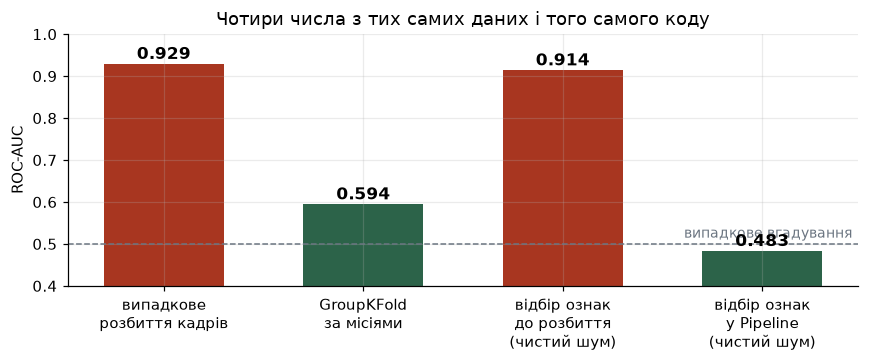

In [9]:
names = ['випадкове\nрозбиття кадрів', 'GroupKFold\nза місіями',
         'відбір ознак\nдо розбиття\n(чистий шум)', 'відбір ознак\nу Pipeline\n(чистий шум)']
vals  = [auc_random, fold_auc.mean(), auc_leak, auc_clean]
cols  = [ALARM, OK, ALARM, OK]

fig, ax = plt.subplots(figsize=(8, 3.4))
bars = ax.bar(names, vals, color=cols, width=.6)
ax.axhline(0.5, color='#6B7581', ls='--', lw=1)
ax.text(3.45, 0.515, 'випадкове вгадування', ha='right', fontsize=9, color='#6B7581')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.012, '%.3f' % v, ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0.4, 1.0); ax.set_ylabel('ROC-AUC')
ax.set_title('Чотири числа з тих самих даних і того самого коду')
plt.tight_layout(); plt.show()

## Що з цього забрати

1. **Питання «яка у вас архітектура» вторинне**, поки не названа одиниця незалежності.
   Тут це `mission_id`; у ваших даних — борт, оператор, ділянка, день.
2. **Усе, що має `.fit()`, живе всередині `Pipeline`** — scaler, PCA, відбір ознак,
   імпутація, SMOTE. Інакше перевірочні дані беруть участь у навчанні.
3. **Label-shuffle** коштує однієї клітинки і хвилини машинного часу.
4. **Метрика без довірчого інтервалу** не дає права казати «краще».

Вимога до ЛР2: групове розбиття + PCA лише всередині пайплайна + ДІ для метрики.